In [9]:
import torch
import numpy as np
import pandas as pd
from tqdm import tqdm
import os

# ===================================================================
# A) Configuration
# ===================================================================
# Directory where your .pt model files are saved
MODEL_DIR = "../data" 
# Directory to save the final standard error results
OUTPUT_DIR = "../output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Define the K values and number of repetitions you ran
K_list = [1, 2, 3]
N_REPETITIONS = 100

print(f"Calculating standard errors for K={K_list} from {N_REPETITIONS} repetitions.")

# ===================================================================
# B) Main Calculation Loop
# ===================================================================
# This list will store the summary results for the final CSV
summary_results = []

# --- Loop over each K value ---
for k in K_list:
    print(f"\n--- Processing K = {k} ---")
    
    # These lists will store the parameters from each repetition for the current K
    theta_reps, a_reps, b_reps = [], [], []
    
    # --- Inner loop to load all repetitions for the current K ---
    pbar = tqdm(range(N_REPETITIONS), desc=f"  Loading reps for K={k}")
    for r in pbar:
        model_path = os.path.join(MODEL_DIR, f"mirt_model_k{k}_rep{r}.pt")
        
        try:
            # Load the saved state from one of your runs
            state = torch.load(model_path, map_location="cpu")
            theta_reps.append(state['theta'].numpy())
            a_reps.append(state['a'].numpy())
            b_reps.append(state['b'].numpy())
        except FileNotFoundError:
            print(f"⚠️ Warning: Skipping missing file: {model_path}")
            continue
            
    # Check if we found any valid files for this K
    if not theta_reps:
        print(f"❌ No model files found for K={k}. Skipping.")
        continue

    # --- Stack parameters from all repetitions into single NumPy arrays ---
    # The first dimension of the stack is the repetition axis
    theta_stack = np.stack(theta_reps, axis=0) # Shape: (N_REPETITIONS, n_persons, k)
    a_stack = np.stack(a_reps, axis=0)       # Shape: (N_REPETITIONS, n_items, k)
    b_stack = np.stack(b_reps, axis=0)       # Shape: (N_REPETITIONS, n_items)

    # --- Calculate Standard Error by taking the standard deviation across repetitions ---
    theta_se = np.std(theta_stack, axis=0, ddof=1)  # Using ddof=1 for sample standard deviation
    a_se = np.std(a_stack, axis=0)
    b_se = np.std(b_stack, axis=0)

    # --- Save the full standard error arrays ---
    se_output_path = os.path.join(OUTPUT_DIR, f"standard_errors_k{k}.npz")
    np.savez_compressed(
        se_output_path,
        theta_se=theta_se,
        a_se=a_se,
        b_se=b_se
    )
    print(f"  ✅ Saved full SE arrays to: {se_output_path}")

    # --- Calculate summary statistics for the CSV file ---
    summary_results.append({
        'K': k,
        'avg_theta_se': np.mean(theta_se),
        'avg_a_se': np.mean(a_se),
        'avg_b_se': np.mean(b_se),
        'num_reps_found': len(theta_reps)
    })

# ===================================================================
# C) Save Summary to CSV
# ===================================================================
summary_df = pd.DataFrame(summary_results)
summary_csv_path = os.path.join(OUTPUT_DIR, "standard_errors_summary.csv")
summary_df.to_csv(summary_csv_path, index=False)

print(f"\n✅ All calculations complete. Summary saved to: {summary_csv_path}")
print("\n--- Summary of Average Standard Errors ---")
print(summary_df)

Calculating standard errors for K=[1, 2, 3] from 100 repetitions.

--- Processing K = 1 ---


  Loading reps for K=1: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:06<00:00, 15.02it/s]


  ✅ Saved full SE arrays to: ../output/standard_errors_k1.npz

--- Processing K = 2 ---


  Loading reps for K=2: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:06<00:00, 14.65it/s]


  ✅ Saved full SE arrays to: ../output/standard_errors_k2.npz

--- Processing K = 3 ---


  Loading reps for K=3: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:07<00:00, 13.72it/s]


  ✅ Saved full SE arrays to: ../output/standard_errors_k3.npz

✅ All calculations complete. Summary saved to: ../output/standard_errors_summary.csv

--- Summary of Average Standard Errors ---
   K  avg_theta_se  avg_a_se  avg_b_se  num_reps_found
0  1      1.993271  0.568036  0.199739             100
1  2      1.940274  0.575852  0.262811             100
2  3      1.782076  0.553607  0.263497             100


In [10]:
import pandas as pd
import os

DATA_DIR = "../data"

results_df = pd.read_csv(os.path.join(DATA_DIR, "mirt_comparison_repeated.csv"))
results_df.sort_values(by=["K", "Test AUC"], ascending=False).groupby("K").head(1)

,Repetition,K,Test AUC,AIC,BIC,Num Params,LogLikelihood
0,0,30,0.892782,7211868.50,3.965619e+07,2445562,-1160372.250
7,1,11,0.893511,4456108.00,1.701371e+07,946557,-1281497.000
11,2,10,0.893778,4375323.00,1.588626e+07,867662,-1319999.500
1,0,9,0.893633,4170361.75,1.463463e+07,788767,-1296413.875
52,3,8,0.893422,4076280.00,1.349388e+07,709872,-1328268.000
5,0,7,0.893155,3936700.50,1.230763e+07,630977,-1337373.250
50,3,6,0.892801,3864888.50,1.118915e+07,552082,-1380362.250
21,0,5,0.891522,3798209.25,1.007580e+07,473187,-1425917.625
20,0,4,0.891534,3741453.50,8.972373e+06,394292,-1476434.750
184,47,3,0.891510,3679949.50,7.864200e+06,315397,-1524577.750


In [12]:
import pandas as pd

resmat = pd.read_pickle("../data/resmat.pkl")

In [ ]:
import numpy as np
import os
from load_params import load_and_rotate

k = 2; r = 87

theta_se = np.load(f"../output/standard_errors_k{k}.npz")['theta_se']
theta, a, b = load_and_rotate(os.path.join(DATA_DIR, f"mirt_model_k{k}_rep{r}.pt"), rotation=None)

data_for_df = {
    'ability_dim1': theta[:, 0],
    'se_dim1':      theta_se[:, 0],
    'ability_dim2': theta[:, 1],
    'se_dim2':      theta_se[:, 1]
}

theta_df = pd.DataFrame(data_for_df, index=resmat.index)

--- Loading from Cache ---
Loaded cached theta shape: (183, 2)
Loaded cached a shape: (78712, 2)
Loaded cached b shape: (78712,)



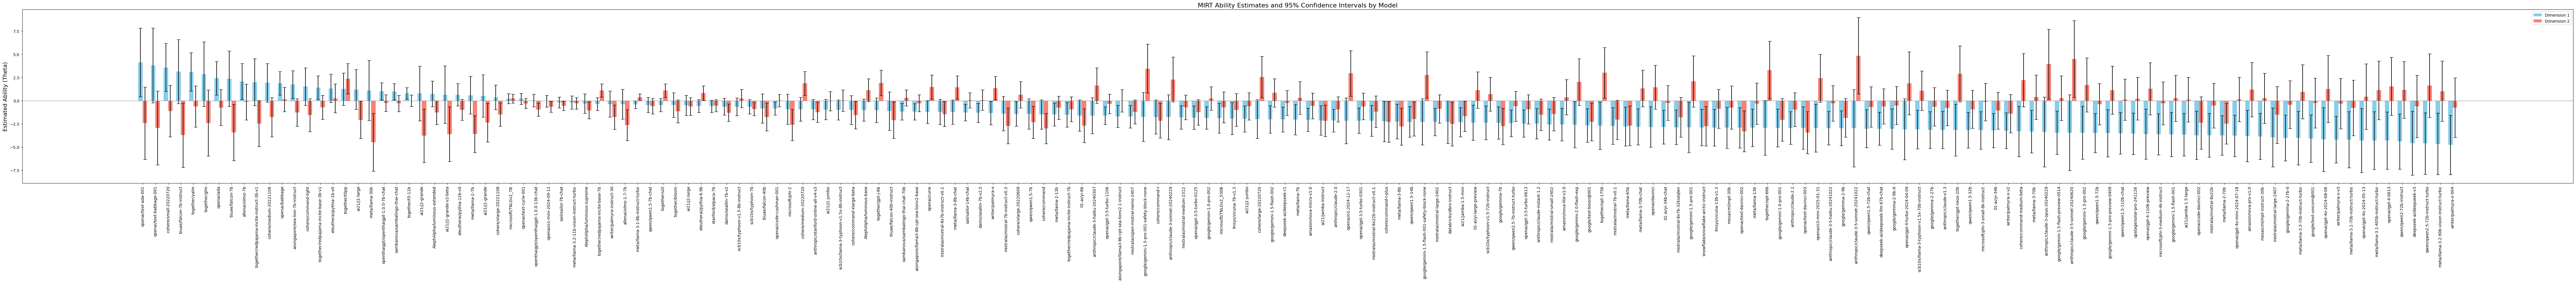

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, sys
sys.path.append('..') 
import style
# plt.rcParams.update(style.rcparams)

# ===================================================================
# B) Create the Plot
# ===================================================================

# --- 1. Sort the DataFrame for a cleaner visualization ---
df_sorted = theta_df.sort_values('ability_dim1', ascending=False)

# --- 2. Set up variables for plotting ---
labels = df_sorted.index
ability1 = df_sorted['ability_dim1']
ability2 = df_sorted['ability_dim2']
# Calculate the 95% confidence interval size (1.96 * SE)
ci1 = df_sorted['se_dim1']
ci2 = df_sorted['se_dim2']

x = np.arange(len(labels))  # the label locations
width = 0.35  # the width of the bars

# --- 3. Create the figure and axes ---
# Increase figsize for better readability with many models
fig, ax = plt.subplots(figsize=(90, 10))

# --- 4. Plot the bars with error bars (whiskers) ---
rects1 = ax.bar(x - width/2, ability1, width, label='Dimension 1', 
                yerr=ci1, capsize=4, color='skyblue')

rects2 = ax.bar(x + width/2, ability2, width, label='Dimension 2', 
                yerr=ci2, capsize=4, color='salmon')

# --- 5. Add text, labels, and title for clarity ---
ax.set_ylabel('Estimated Ability (Theta)', fontsize=14)
ax.set_title('MIRT Ability Estimates and 95% Confidence Intervals by Model', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

# --- 6. Rotate x-axis labels as requested ---
plt.xticks(rotation=90)

# Add a horizontal line at y=0 for reference
ax.axhline(0, color='grey', linewidth=0.8)

fig.tight_layout()  # Adjust layout to make room for rotated labels

# Save the plot
plt.savefig(f'../output/dual_dimension_ability_plot_k{k}.pdf', bbox_inches='tight')

plt.show()

In [ ]:
import numpy as np
import os
import torch
from load_params import load_and_rotate

k = 1; r= 93

theta_se = np.load(f"../output/standard_errors_k{k}.npz")['theta_se']
theta, a, b = load_and_rotate(os.path.join(DATA_DIR, f"mirt_model_k{k}_rep{r}.pt"), rotation=None)

data_for_df = {
    'ability_dim1': theta[:, 0],
    'se_dim1':      theta_se[:, 0]
}

theta_df = pd.DataFrame(data_for_df, index=resmat.index)

--- Loading from Cache ---
Loaded cached theta shape: (183, 1)
Loaded cached a shape: (78712, 1)
Loaded cached b shape: (78712,)



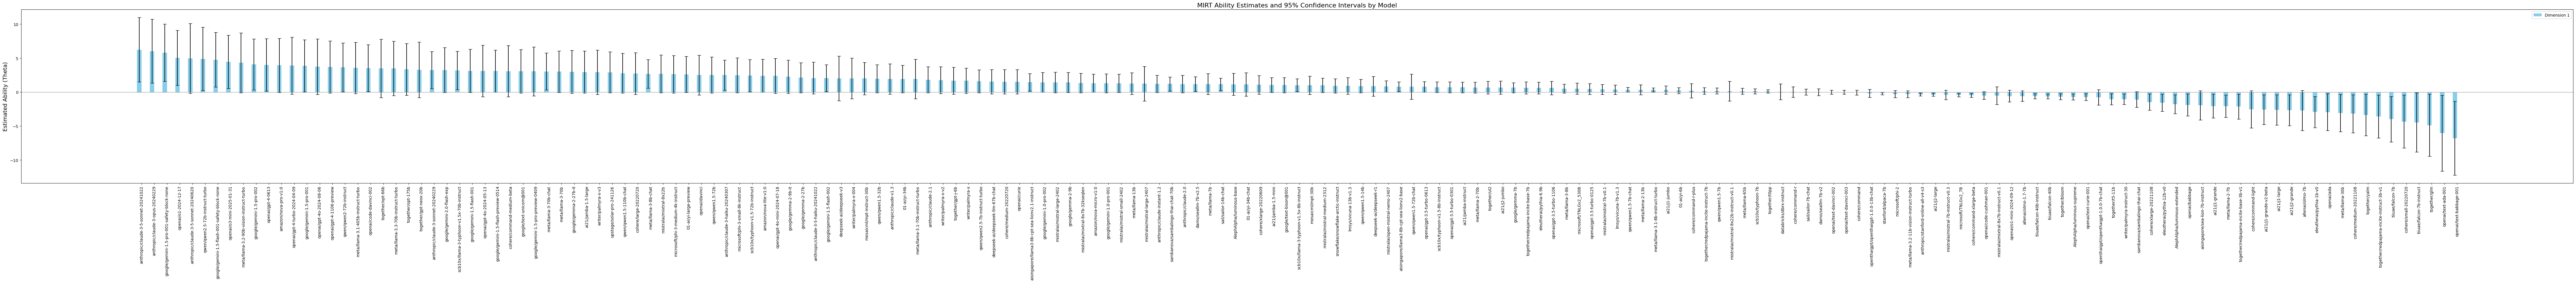

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, sys
sys.path.append('..') 
import style
# plt.rcParams.update(style.rcparams)

# ===================================================================
# B) Create the Plot
# ===================================================================

# --- 1. Sort the DataFrame for a cleaner visualization ---
df_sorted = theta_df.sort_values('ability_dim1', ascending=False)

# --- 2. Set up variables for plotting ---
labels = df_sorted.index
ability1 = df_sorted['ability_dim1']
# ability2 = df_sorted['ability_dim2']
# Calculate the 95% confidence interval size (1.96 * SE)
ci1 = df_sorted['se_dim1']
# ci2 = df_sorted['se_dim2']

x = np.arange(len(labels))  # the label locations
width = 0.35  # the width of the bars

# --- 3. Create the figure and axes ---
# Increase figsize for better readability with many models
fig, ax = plt.subplots(figsize=(90, 10))

# --- 4. Plot the bars with error bars (whiskers) ---
rects1 = ax.bar(x - width/2, ability1, width, label='Dimension 1', 
                yerr=ci1, capsize=4, color='skyblue')

# rects2 = ax.bar(x + width/2, ability2, width, label='Dimension 2', 
#                 yerr=ci2, capsize=4, color='salmon')

# --- 5. Add text, labels, and title for clarity ---
ax.set_ylabel('Estimated Ability (Theta)', fontsize=14)
ax.set_title('MIRT Ability Estimates and 95% Confidence Intervals by Model', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

# --- 6. Rotate x-axis labels as requested ---
plt.xticks(rotation=90)

# Add a horizontal line at y=0 for reference
ax.axhline(0, color='grey', linewidth=0.8)

fig.tight_layout()  # Adjust layout to make room for rotated labels

# Save the plot
plt.savefig(f'../output/dual_dimension_ability_plot_k{k}.pdf', bbox_inches='tight')

plt.show()

In [38]:
import pandas as pd

# Load your response matrix (assuming it's in a .pkl file)
resmat = pd.read_pickle("../data/resmat.pkl")

# Calculate the mean score for each model (row), ignoring NaNs
# This is the raw accuracy on the subset of tasks each model was tested on.
average_score_baseline = resmat.mean(axis=1)

# Create a DataFrame for a clean display
baseline_df = pd.DataFrame({
    'raw_accuracy': average_score_baseline
}, index=resmat.index).sort_values(by='raw_accuracy', ascending=False)

print("--- Naive Raw Accuracy Baseline ---")
print(baseline_df.head(10))

--- Naive Raw Accuracy Baseline ---
                                               raw_accuracy
request.model                                              
google/gemini-1.5-pro-001-safety-block-none        0.873019
anthropic/claude-3-5-sonnet-20241022               0.869802
anthropic/claude-3-5-sonnet-20240620               0.855008
anthropic/claude-3-opus-20240229                   0.831202
openai/o1-2024-12-17                               0.827482
qwen/qwen2.5-72b-instruct-turbo                    0.821147
google/gemini-1.5-flash-001-safety-block-none      0.818255
google/gemini-1.5-pro-002                          0.808939
amazon/nova-pro-v1:0                               0.806270
google/gemini-1.5-pro-preview-0409                 0.805339


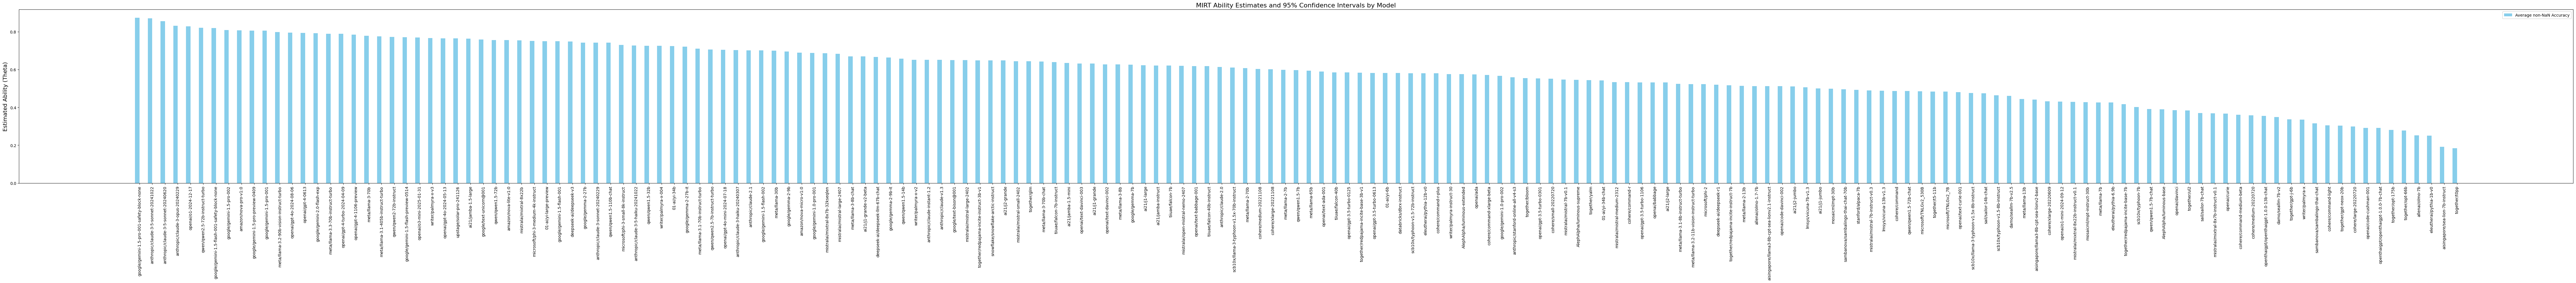

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, sys
sys.path.append('..') 
import style
# plt.rcParams.update(style.rcparams)

# ===================================================================
# B) Create the Plot
# ===================================================================

# --- 1. Sort the DataFrame for a cleaner visualization ---
df_sorted = baseline_df.sort_values('raw_accuracy', ascending=False)

# --- 2. Set up variables for plotting ---
labels = df_sorted.index
ability1 = df_sorted['raw_accuracy']

x = np.arange(len(labels))  # the label locations
width = 0.35  # the width of the bars

# --- 3. Create the figure and axes ---
# Increase figsize for better readability with many models
fig, ax = plt.subplots(figsize=(90, 10))

# --- 4. Plot the bars with error bars (whiskers) ---
rects1 = ax.bar(x - width/2, ability1, width, label='Average non-NaN Accuracy', 
                capsize=4, color='skyblue')

# --- 5. Add text, labels, and title for clarity ---
ax.set_ylabel('Estimated Ability (Theta)', fontsize=14)
ax.set_title('MIRT Ability Estimates and 95% Confidence Intervals by Model', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

# --- 6. Rotate x-axis labels as requested ---
plt.xticks(rotation=90)

# Add a horizontal line at y=0 for reference
ax.axhline(0, color='grey', linewidth=0.8)

fig.tight_layout()  # Adjust layout to make room for rotated labels

# Save the plot
plt.savefig(f'../output/dual_dimension_ability_plot_average_non_nan.pdf', bbox_inches='tight')

plt.show()

In [41]:
import pandas as pd

# Load your response matrix (assuming it's in a .pkl file)
resmat = pd.read_pickle("../data/resmat.pkl")

# Calculate the mean score for each model (row), ignoring NaNs
# This is the raw accuracy on the subset of tasks each model was tested on.
average_nan_score_baseline = resmat.fillna(0).mean(axis=1)

# Create a DataFrame for a clean display
baseline_df = pd.DataFrame({
    'raw_accuracy': average_nan_score_baseline
}, index=resmat.index).sort_values(by='raw_accuracy', ascending=False)

print("--- Naive Raw Accuracy Baseline ---")
print(baseline_df.head(10))

--- Naive Raw Accuracy Baseline ---
                           raw_accuracy
request.model                          
openai/gpt-3.5-turbo-0613      0.565136
meta/llama-2-70b               0.550539
meta/llama-2-7b                0.543284
mistralai/mistral-7b-v0.1      0.496646
ai21/j2-grande                 0.493368
openai/text-davinci-003        0.480981
openai/text-davinci-002        0.477704
meta/llama-30b                 0.473397
ai21/j1-grande-v2-beta         0.467896
meta/llama-2-13b               0.465977


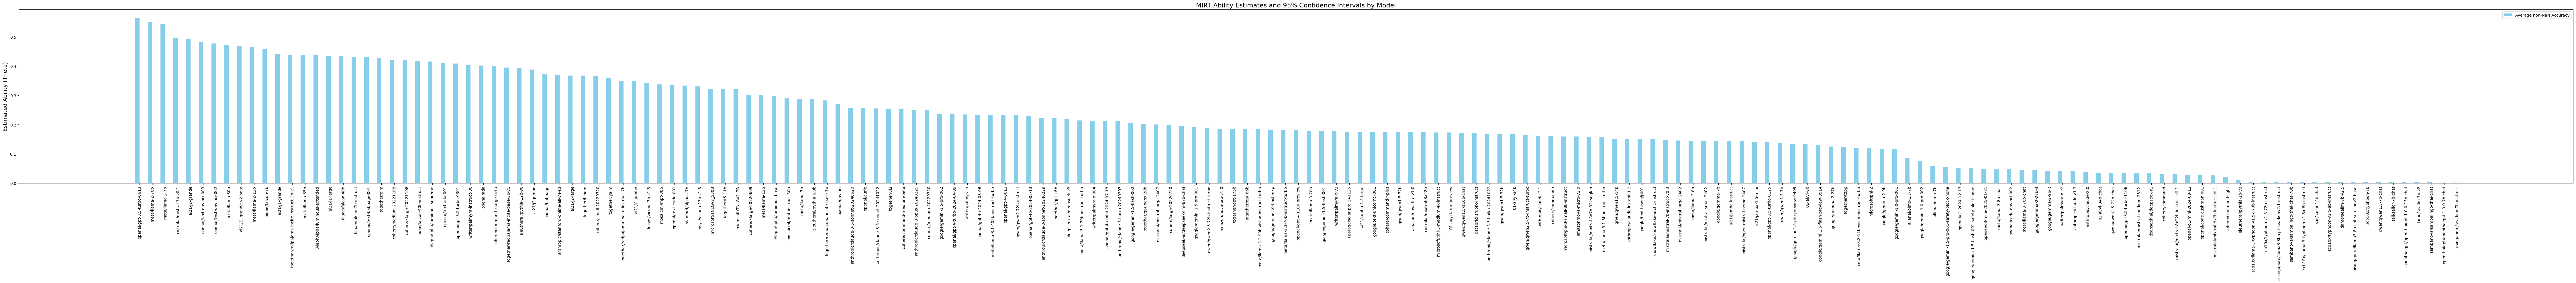

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, sys
sys.path.append('..') 
import style
# plt.rcParams.update(style.rcparams)

# ===================================================================
# B) Create the Plot
# ===================================================================

# --- 1. Sort the DataFrame for a cleaner visualization ---
df_sorted = baseline_df.sort_values('raw_accuracy', ascending=False)

# --- 2. Set up variables for plotting ---
labels = df_sorted.index
ability1 = df_sorted['raw_accuracy']

x = np.arange(len(labels))  # the label locations
width = 0.35  # the width of the bars

# --- 3. Create the figure and axes ---
# Increase figsize for better readability with many models
fig, ax = plt.subplots(figsize=(90, 10))

# --- 4. Plot the bars with error bars (whiskers) ---
rects1 = ax.bar(x - width/2, ability1, width, label='Average non-NaN Accuracy', 
                capsize=4, color='skyblue')

# --- 5. Add text, labels, and title for clarity ---
ax.set_ylabel('Estimated Ability (Theta)', fontsize=14)
ax.set_title('MIRT Ability Estimates and 95% Confidence Intervals by Model', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

# --- 6. Rotate x-axis labels as requested ---
plt.xticks(rotation=90)

# Add a horizontal line at y=0 for reference
ax.axhline(0, color='grey', linewidth=0.8)

fig.tight_layout()  # Adjust layout to make room for rotated labels

# Save the plot
plt.savefig(f'../output/dual_dimension_ability_plot_average_nan.pdf', bbox_inches='tight')

plt.show()